imports

In [1]:
import os
import sys
import matplotlib as mpl

sys.path.append("..")
mpl.rcParams["animation.embed_limit"] = 100

from cleanroom_cfd.config import SimulationConfig
from cleanroom_cfd.setup import (
    build_room_setup,
    build_initial_fields,
)
from cleanroom_cfd.data_pipeline import (
    load_timeline_window,
    build_machine_state,
    build_screen_state,
    build_human_entities_for_time,
    update_machine_entities_for_time,
    update_screen_entities_for_time,
)
from cleanroom_cfd.simulation import compute_time_step, compute_tau_field, cfd_step
from cleanroom_cfd.analysis import run_simulation_and_collect, save_metric_plots
from cleanroom_cfd.visualization import animate_simulation

experiment settings


In [2]:
cfg = SimulationConfig()

csv_path = "../assets/v2_object_timeline_temperature.csv"
svg_path = "../assets/Feynmann room_inked_good.svg"
results_dir = "../results"

table_window_minutes = 60
window_start_timestamp = "2025-04-23 14:29:00"
save_interval_s = 30.0

cfg.res = 10
cfg.sock_speed = 0.45
cfg.supply_temp = 20.0
cfg.target_time = table_window_minutes * 60
cfg.frames = int(cfg.target_time / save_interval_s)

os.makedirs(results_dir, exist_ok=True)

load timeline data

In [3]:
timeline_data = load_timeline_window(
    csv_path=csv_path,
    table_window_minutes=table_window_minutes,
    window_start_timestamp=window_start_timestamp,
)

print("Window start:", timeline_data["first_ts"])
print("Window end:", timeline_data["end_ts"])
print("Rows in window:", len(timeline_data["df_window"]))
print("Unique timestamps in window:", len(timeline_data["unique_times"]))
print("labels in window:", sorted(timeline_data["df_window"]["label"].dropna().unique().tolist()))

Window start: 2025-04-23 14:29:00
Window end: 2025-04-23 15:29:00
Rows in window: 501
Unique timestamps in window: 49
labels in window: ['Light', 'Machine', 'Person', 'Screen', 'Window']


geometry and room setup

In [4]:
room = build_room_setup(cfg, svg_path)

print("Room size:", room["svg_width_m"], "x", room["svg_height_m"])
print("Grid:", room["grid_w"], "x", room["grid_h"])
print("Sock rows:", room["src_y0"], room["src_y1"])

Room size: 15.0 x 12.0
Grid: 150 x 120
Sock rows: 78 82


build static entities and machine state

In [5]:
base_entities_list = [
    # Middle passthrough furniture
    room["entity_factory"]("furniture_passthrough", x_m=2.0, y_m=3.8, width_m=8.8, height_m=2.3, id_name="middle_1"),
    room["entity_factory"]("furniture_passthrough", x_m=10.8, y_m=3.0, width_m=1.0, height_m=3.1, id_name="middle_2"),

    # Existing passthrough furniture
    room["entity_factory"]("furniture_passthrough", x_m=1.8, y_m=0.0, width_m=3.6, height_m=1.0, id_name="table_1"),
    room["entity_factory"]("furniture_passthrough", x_m=5.7, y_m=0.0, width_m=3.9, height_m=1.0, id_name="table_2"),
    room["entity_factory"]("furniture_passthrough", x_m=9.8, y_m=0.0, width_m=3.8, height_m=1.0, id_name="table_3"),
]

# -----------------------------
# Machines
# -----------------------------
machine_state = build_machine_state(
    df_window=timeline_data["df_window"],
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    machine_radius_m=0.30,
)

persistent_machine_entities = machine_state["persistent_machine_entities"]
machine_entity_map = machine_state["machine_entity_map"]
machine_temp_lookup = machine_state["machine_temp_lookup"]

# -----------------------------
# Screens
# -----------------------------
screen_state = build_screen_state(
    df_window=timeline_data["df_window"],
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    screen_radius_m=0.18,
)

persistent_screen_entities = screen_state["persistent_screen_entities"]
screen_entity_map = screen_state["screen_entity_map"]
screen_temp_lookup = screen_state["screen_temp_lookup"]

# Combined hot entities (for tau field only)
persistent_hot_entities = persistent_machine_entities + persistent_screen_entities

print("Persistent machines created:", len(persistent_machine_entities))
print("Persistent screens created:", len(persistent_screen_entities))

Persistent machines created: 5
Persistent screens created: 1


initial fields and tau field

In [6]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

dt = compute_time_step(room["dx"], cfg.sock_speed, cfg.alpha_heat, cfg.nu_eff)

tau_field = compute_tau_field(
    (room["grid_h"], room["grid_w"]),
    room["src_y0"],
    room["src_y1"],
    room["is_obstacle"],
    base_entities_list + persistent_hot_entities,
    cfg.res,
    tau_min=100,
    tau_max=400,
)

substeps_per_frame = int(save_interval_s / dt)

print("dt =", dt)
print("frames =", cfg.frames)
print("save interval (s) =", save_interval_s)
print("substeps_per_frame =", substeps_per_frame)
print("total simulated time represented =", cfg.frames * substeps_per_frame * dt)

dt = 0.06666666666666667
frames = 120
save interval (s) = 30.0
substeps_per_frame = 450
total simulated time represented = 3600.0


step function

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Controller settings
# ============================================================

T_LIMIT_C = 23.0          # maximum allowed ambient temperature
SUPPLY_MIN_C = 16.0       # coldest allowed supply air
SUPPLY_MAX_C = 22.0       # warmest allowed supply air
INITIAL_SUPPLY_C = 20.0   # starting supply temperature

CONTROL_INTERVAL_S = 300.0   # controller update period: 5 minutes
SUPPLY_STEP_C = 0.5           # controller step size
RAMP_LIMIT_C = 0.5            # max change per controller update

EMERGENCY_MARGIN_C = 0.3      # full cooling when T > T_LIMIT - 0.3
COOLING_MARGIN_C = 0.8        # increase cooling when T > T_LIMIT - 0.8
RELAX_MARGIN_C = 2.0          # reduce cooling when T < T_LIMIT - 2.0


# ============================================================
# Controller helper functions
# ============================================================

def get_room_max_temperature(T, is_obstacle):
    """
    Returns max cleanroom air temperature, excluding obstacles.
    This is conservative: it controls the hottest point in the room.
    """
    valid = ~is_obstacle

    # Optional: exclude supply inlet cells from control metric.
    # They are cold by design and should not influence max anyway,
    # but this keeps the metric clean.
    valid = valid.copy()
    valid[room["src_y0"]:room["src_y1"], :] = False

    values = T[valid]
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return float(np.nan)

    return float(np.max(values))


def hysteresis_supply_controller(T_control, supply_prev):
    """
    Hysteresis controller for supply air temperature.

    Lower supply temperature = stronger cooling.
    Higher supply temperature = weaker cooling.
    """

    if T_control >= T_LIMIT_C - EMERGENCY_MARGIN_C:
        # Very close to the limit: maximum cooling
        supply_target = SUPPLY_MIN_C

    elif T_control >= T_LIMIT_C - COOLING_MARGIN_C:
        # Getting warm: increase cooling
        supply_target = supply_prev - SUPPLY_STEP_C

    elif T_control <= T_LIMIT_C - RELAX_MARGIN_C:
        # Safely cold: reduce cooling
        supply_target = supply_prev + SUPPLY_STEP_C

    else:
        # Inside deadband: keep previous setting
        supply_target = supply_prev

    supply_target = float(np.clip(supply_target, SUPPLY_MIN_C, SUPPLY_MAX_C))

    # Ramp-rate limit
    delta = np.clip(
        supply_target - supply_prev,
        -RAMP_LIMIT_C,
        RAMP_LIMIT_C
    )

    supply_new = supply_prev + delta
    supply_new = float(np.clip(supply_new, SUPPLY_MIN_C, SUPPLY_MAX_C))

    return supply_new


def reset_controller(initial_supply_temp=INITIAL_SUPPLY_C, enabled=True):
    """
    Reset simulation time, dynamic people state, and controller state.
    Call this before every new simulation run.
    """
    global sim_time_state
    global dynamic_entities_state
    global controller_state

    sim_time_state = {"t": 0.0}
    dynamic_entities_state = {"humans": []}

    controller_state = {
        "enabled": enabled,
        "supply_temp": float(initial_supply_temp),
        "next_control_time_s": 0.0,
        "log": [],
    }


# Initialize controller state once
reset_controller(initial_supply_temp=INITIAL_SUPPLY_C, enabled=True)


# ============================================================
# Controlled simulation step
# ============================================================

def step_fn(T, tracer, u, v, p):
    t = sim_time_state["t"]

    # --------------------------------------------------------
    # Controller update
    # --------------------------------------------------------
    if t >= controller_state["next_control_time_s"]:
        T_control = get_room_max_temperature(T, room["is_obstacle"])
        supply_prev = controller_state["supply_temp"]

        if controller_state["enabled"]:
            supply_new = hysteresis_supply_controller(
                T_control=T_control,
                supply_prev=supply_prev
            )
        else:
            # Constant-supply baseline mode
            supply_new = supply_prev

        controller_state["supply_temp"] = supply_new
        controller_state["next_control_time_s"] += CONTROL_INTERVAL_S

        controller_state["log"].append({
            "time_s": t,
            "time_min": t / 60.0,
            "T_room_max_C": T_control,
            "supply_temp_C": supply_new,
            "controller_enabled": controller_state["enabled"],
        })

    # --------------------------------------------------------
    # Update machines and humans
    # --------------------------------------------------------
    update_machine_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        machine_entity_map=machine_entity_map,
        machine_temp_lookup=machine_temp_lookup,
        grace_period_minutes=3,
    )

    update_screen_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        screen_entity_map=screen_entity_map,
        screen_temp_lookup=screen_temp_lookup,
        grace_period_minutes=3,
    )

    human_entities = build_human_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        rows_by_time=timeline_data["rows_by_time"],
        svg_width_m=room["svg_width_m"],
        svg_height_m=room["svg_height_m"],
    )

    dynamic_entities_state["humans"] = human_entities
    entities_list = base_entities_list + persistent_machine_entities + persistent_screen_entities + human_entities

    # --------------------------------------------------------
    # CFD step with controlled supply temperature
    # --------------------------------------------------------
    out = cfd_step(
        T, tracer, u, v, p,
        dx=room["dx"],
        dt=dt,
        entities_list=entities_list,
        is_obstacle=room["is_obstacle"],
        res=cfg.res,
        src_y0=room["src_y0"],
        src_y1=room["src_y1"],
        hs_x=room["hs_x"],
        hs_y=room["hs_y"],
        bubble_r=cfg.bubble_r,
        alpha_heat=cfg.alpha_heat,
        nu_eff=cfg.nu_eff,
        rho=cfg.rho,
        beta_b=cfg.beta_b,
        g=cfg.g,
        T_ref=cfg.T_ref,
        sock_speed=cfg.sock_speed,

        # This is the actual control input
        supply_temp=controller_state["supply_temp"],

        smoke_diff=cfg.smoke_diff,
        pressure_iters=cfg.pressure_iters,
        max_speed=cfg.max_speed,
        tau_field=tau_field,
    )

    sim_time_state["t"] += dt
    return out

run analysis

In [8]:
# ============================================================
# Run controlled simulation
# ============================================================

cfg.supply_temp = INITIAL_SUPPLY_C

thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=INITIAL_SUPPLY_C,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

reset_controller(
    initial_supply_temp=INITIAL_SUPPLY_C,
    enabled=True
)

df_metrics, final_state = run_simulation_and_collect(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    dt=dt,
    is_obstacle=room["is_obstacle"],
    machine_entities=persistent_machine_entities,
    res=cfg.res,
    real_start_timestamp=timeline_data["first_ts"],
    use_circular_machine_metrics=True,
    default_machine_radius_m=0.30,
    surround_outer_radius_m=0.60,
)

df_control = pd.DataFrame(controller_state["log"])

csv_path = save_metric_plots(df_metrics, results_dir)
control_csv_path = os.path.join(results_dir, "controller_log.csv")
df_control.to_csv(control_csv_path, index=False)

print("Saved results to:", results_dir)
print("Metrics CSV:", csv_path)
print("Controller CSV:", control_csv_path)

display(df_metrics.head())
display(df_control.head())

Saved results to: ../results
Metrics CSV: ../results\metrics.csv
Controller CSV: ../results\controller_log.csv


,room_avg_temp,room_max_temp,room_min_temp,room_std_temp,room_avg_speed,room_max_speed,machine_machine_1_box_temp,machine_machine_1_surround_temp,machine_machine_2_box_temp,machine_machine_2_surround_temp,machine_machine_3_box_temp,machine_machine_3_surround_temp,machine_machine_4_box_temp,machine_machine_4_surround_temp,machine_machine_6_box_temp,machine_machine_6_surround_temp,frame,sim_time_s,sim_time_min,real_datetime
0,20.813730,30.009953,20.515230,0.635482,0.0,0.0,NaN,20.774584,26.880054,20.973807,24.909533,21.139652,23.013527,20.959344,23.195072,20.979451,1,30.0,0.5,2025-04-23 14:29:30
1,20.782698,30.009953,20.512109,0.648719,0.0,0.0,NaN,20.751499,26.880054,21.129136,24.909905,21.264732,23.013688,21.015594,23.195435,21.038835,2,60.0,1.0,2025-04-23 14:30:00
2,20.755801,30.009953,20.509877,0.657373,0.0,0.0,NaN,20.730467,26.880054,21.242591,24.910054,21.328054,23.013746,21.038946,23.195548,21.062878,3,90.0,1.5,2025-04-23 14:30:30
3,20.733054,30.009953,20.508154,0.663995,0.0,0.0,NaN,20.711279,26.880054,21.330026,24.910134,21.365514,23.013773,21.048970,23.195596,21.074511,4,120.0,2.0,2025-04-23 14:31:00
4,20.713908,30.009953,20.506753,0.669347,0.0,0.0,NaN,20.693759,26.880054,21.400637,24.910184,21.389825,23.013788,21.052935,23.195621,21.080808,5,150.0,2.5,2025-04-23 14:31:30


,time_s,time_min,T_room_max_C,supply_temp_C,controller_enabled
0,0.000000,0.000000,20.800000,20.5,True
1,300.066667,5.001111,25.979546,20.0,True
2,600.000000,10.000000,24.504578,19.5,True
3,900.000000,15.000000,24.214445,19.0,True
4,1200.000000,20.000000,24.192940,18.5,True


save gif

In [9]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}

gif_path = os.path.join(results_dir, "simulation.gif")

anim = animate_simulation(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    is_obstacle=room["is_obstacle"],
    y_sock_m=cfg.y_sock_m,
    sock_thickness_m=cfg.sock_thickness_m,
    hs_x_m=cfg.hotspot_x_m,
    hs_y_m=cfg.hotspot_y_m,
    v_sock_target=cfg.sock_speed,
    T_supply=cfg.supply_temp,
    dt=dt,
    entities_list=base_entities_list + persistent_machine_entities + persistent_screen_entities,
    real_start_timestamp=timeline_data["first_ts"],
    dynamic_entities_state=dynamic_entities_state,
    save_gif_path=gif_path,
    gif_fps=8,
    show_inline=False,
)

print("Saved GIF to:", gif_path)

Saved GIF to: ../results\simulation.gif


Save results


df_metrics columns:
['room_avg_temp', 'room_max_temp', 'room_min_temp', 'room_std_temp', 'room_avg_speed', 'room_max_speed', 'machine_machine_1_box_temp', 'machine_machine_1_surround_temp', 'machine_machine_2_box_temp', 'machine_machine_2_surround_temp', 'machine_machine_3_box_temp', 'machine_machine_3_surround_temp', 'machine_machine_4_box_temp', 'machine_machine_4_surround_temp', 'machine_machine_6_box_temp', 'machine_machine_6_surround_temp', 'frame', 'sim_time_s', 'sim_time_min', 'real_datetime']

===== Controlled simulation summary =====
Temperature column used: room_max_temp
Max room temperature [C]: 30.01
Temperature limit [C]: 23.0
Minutes above limit: 60.0
Cooling energy proxy: 14850.0
Number of supply setpoint changes: 9


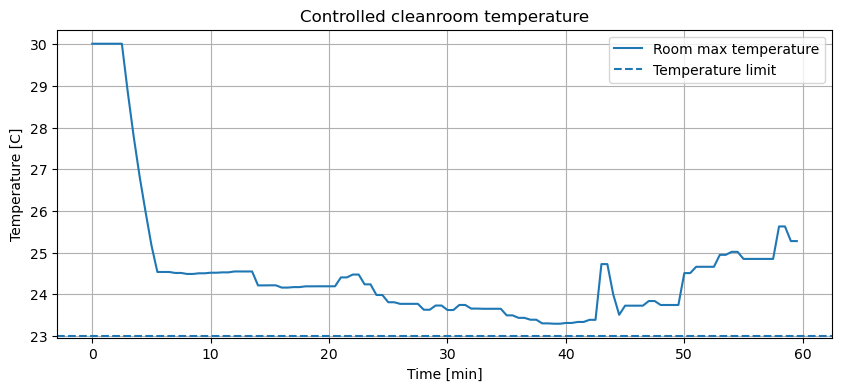

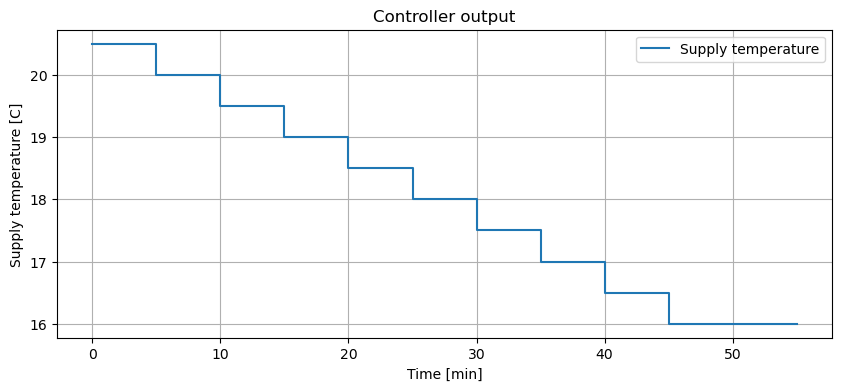

In [10]:
# ============================================================
# Controller evaluation plots and summary
# ============================================================

def find_temperature_column(df):
    """
    Try to find the max room temperature column from df_metrics.
    This makes the code robust to slightly different column names.
    """
    candidates = [
        "room_max_temp",
        "room_max_temp_C",
        "room_max_temperature",
        "max_temp",
        "max_temperature",
        "T_max",
        "T_room_max",
        "T_room_max_C",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    # Fallback: search for likely column names
    for col in df.columns:
        name = col.lower()
        if "max" in name and ("temp" in name or "temperature" in name or name.startswith("t_")):
            return col

    return None


def get_metric_time_minutes(df):
    if "time_s" in df.columns:
        return df["time_s"] / 60.0
    if "time_min" in df.columns:
        return df["time_min"]
    if "time" in df.columns:
        return df["time"] / 60.0

    return np.arange(len(df)) * save_interval_s / 60.0

def res():
    temp_col = find_temperature_column(df_metrics)
    metric_time_min = get_metric_time_minutes(df_metrics)

    print("df_metrics columns:")
    print(list(df_metrics.columns))

    if temp_col is None:
        print("\nCould not automatically find the max temperature column.")
        print("Pick the correct column from the printed list above and set temp_col manually.")
    else:
        max_temp = float(df_metrics[temp_col].max())
        minutes_above_limit = float(np.sum(df_metrics[temp_col] > T_LIMIT_C) * save_interval_s / 60.0)

        if len(df_control) > 1:
            energy_proxy = float(np.sum((SUPPLY_MAX_C - df_control["supply_temp_C"]) * CONTROL_INTERVAL_S))
            setpoint_changes = int(np.sum(np.abs(np.diff(df_control["supply_temp_C"])) > 1e-9))
        else:
            energy_proxy = np.nan
            setpoint_changes = 0

        print("\n===== Controlled simulation summary =====")
        print("Temperature column used:", temp_col)
        print("Max room temperature [C]:", round(max_temp, 3))
        print("Temperature limit [C]:", T_LIMIT_C)
        print("Minutes above limit:", round(minutes_above_limit, 3))
        print("Cooling energy proxy:", round(energy_proxy, 3))
        print("Number of supply setpoint changes:", setpoint_changes)

        # Temperature plot
        plt.figure(figsize=(10, 4))
        plt.plot(metric_time_min, df_metrics[temp_col], label="Room max temperature")
        plt.axhline(T_LIMIT_C, linestyle="--", label="Temperature limit")
        plt.xlabel("Time [min]")
        plt.ylabel("Temperature [C]")
        plt.title("Controlled cleanroom temperature")
        plt.legend()
        plt.grid(True)
        plt.show()

        # Supply temperature plot
        plt.figure(figsize=(10, 4))
        plt.step(df_control["time_min"], df_control["supply_temp_C"], where="post", label="Supply temperature")
        plt.xlabel("Time [min]")
        plt.ylabel("Supply temperature [C]")
        plt.title("Controller output")
        plt.legend()
        plt.grid(True)
        plt.show()

res()

Baseline

Baseline temperature column: room_max_temp

===== Constant baseline summary =====
Baseline supply temp [C]: 20.0
Max room temperature [C]: 30.01
Minutes above limit: 60.0


NameError: name 'metric_time_min' is not defined

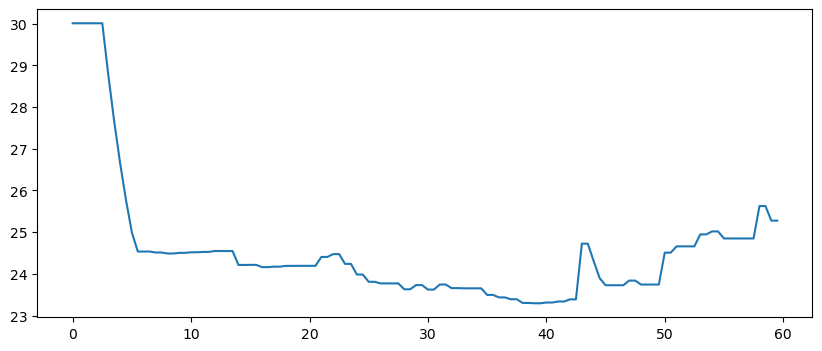

In [11]:
# ============================================================
# Constant-supply baseline
# ============================================================

BASELINE_SUPPLY_C = 20.0

thermal_grid_base, sock_tracer_base, u_vel_base, v_vel_base, p_base = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=BASELINE_SUPPLY_C,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

reset_controller(
    initial_supply_temp=BASELINE_SUPPLY_C,
    enabled=False
)

df_metrics_baseline, final_state_baseline = run_simulation_and_collect(
    thermal_grid_base, sock_tracer_base, u_vel_base, v_vel_base, p_base,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    dt=dt,
    is_obstacle=room["is_obstacle"],
    machine_entities=persistent_machine_entities,
    res=cfg.res,
    real_start_timestamp=timeline_data["first_ts"],
    use_circular_machine_metrics=True,
    default_machine_radius_m=0.30,
    surround_outer_radius_m=0.60,
)

df_control_baseline = pd.DataFrame(controller_state["log"])

temp_col_base = find_temperature_column(df_metrics_baseline)
metric_time_min_base = get_metric_time_minutes(df_metrics_baseline)

print("Baseline temperature column:", temp_col_base)

if temp_col_base is not None:
    print("\n===== Constant baseline summary =====")
    print("Baseline supply temp [C]:", BASELINE_SUPPLY_C)
    print("Max room temperature [C]:", round(float(df_metrics_baseline[temp_col_base].max()), 3))
    print("Minutes above limit:", round(float(np.sum(df_metrics_baseline[temp_col_base] > T_LIMIT_C) * save_interval_s / 60.0), 3))

    plt.figure(figsize=(10, 4))
    plt.plot(metric_time_min_base, df_metrics_baseline[temp_col_base], label="Constant baseline")
    plt.plot(metric_time_min, df_metrics[temp_col], label="Controlled")
    plt.axhline(T_LIMIT_C, linestyle="--", label="Temperature limit")
    plt.xlabel("Time [min]")
    plt.ylabel("Temperature [C]")
    plt.title("Baseline vs controlled cleanroom temperature")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
res()